In [1]:
"""
Scaling of Triplet Clustering
---------------------------------------------------------

This notebook is an edited version of the docs from HDBSCAN:
https://github.com/scikit-learn-contrib/hdbscan/blob/master/docs/performance_and_scalability.rst
"""
import tripletclustering
import fast_hdbscan
import sklearn.datasets
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('poster')
sns.set_palette('Paired', 10)
sns.set_color_codes()

# Scaling with number of points (n)

In [2]:
def benchmark_algorithm(
    dataset_sizes,
    cluster_function,
    function_args,
    function_kwds,
    dataset_dimension=10,
    dataset_n_clusters=10,
    max_time=45,
    sample_size=5
    ):
    
    # Initialize the result with NaNs so that any unfilled entries 
    # will be considered NULL when we convert to a pandas dataframe at the end
    result = np.nan * np.ones((len(dataset_sizes), sample_size))
    for index, size in enumerate(dataset_sizes):
        for s in range(sample_size):
            # Use sklearns make_blobs to generate a random dataset with specified size
            # dimension and number of clusters
            data, labels = sklearn.datasets.make_blobs(n_samples=size, 
                                                        n_features=dataset_dimension, 
                                                        centers=dataset_n_clusters)
            
            # Start the clustering with a timer
            start_time = time.time()
            cluster_function(data, *function_args, **function_kwds)
            time_taken = time.time() - start_time
            
            # If we are taking more than max_time then abort -- we don't
            # want to spend excessive time on slow algorithms
            if time_taken > max_time:
                result[index, s] = time_taken
                return pd.DataFrame(np.vstack([dataset_sizes.repeat(sample_size), 
                                                result.flatten()]).T, columns=['x','y'])
            else:
                result[index, s] = time_taken
        
    # Return the result as a dataframe for easier handling with seaborn afterwards
    return pd.DataFrame(np.vstack([dataset_sizes.repeat(sample_size), 
                                    result.flatten()]).T, columns=['x','y'])

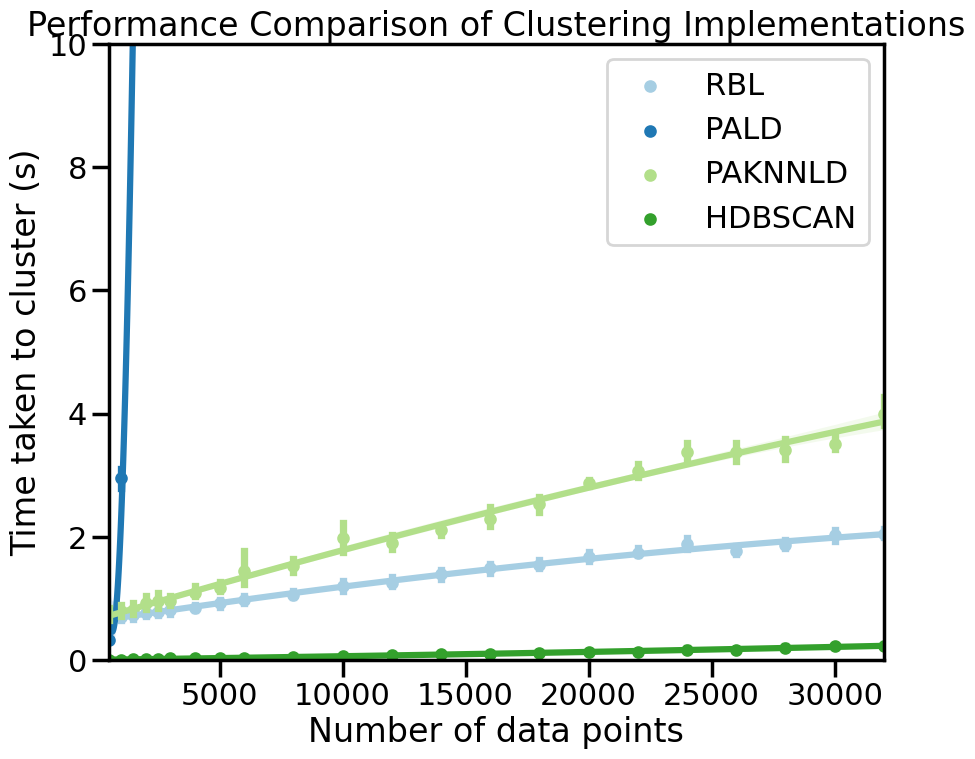

In [3]:
# Small datasets
dataset_sizes = np.hstack([np.arange(1, 6) * 500, np.arange(3,7) * 1000, np.arange(4,17) * 2000])

# Data to fit each model to compile the numba parts
data, labels = sklearn.datasets.make_blobs(n_samples=100, n_features=3, centers=2)

rbl = tripletclustering.TripletClustering(similarity_method="rbl")
rbl.fit(data)
rbl_data = benchmark_algorithm(dataset_sizes, rbl.fit, (), {})

pald = tripletclustering.TripletClustering(similarity_method="pald")
pald.fit(data)
pald_data = benchmark_algorithm(dataset_sizes, pald.fit, (), {})

paknnld = tripletclustering.TripletClustering(similarity_method="paknnld")
paknnld.fit(data)
paknnld_data = benchmark_algorithm(dataset_sizes, paknnld.fit, (), {})

hdbscan = fast_hdbscan.HDBSCAN()
hdbscan.fit(data)
hdbscan_data = benchmark_algorithm(dataset_sizes, hdbscan.fit, (), {})

plt.figure(figsize=(10, 8))

sns.regplot(x='x', y='y', data=rbl_data, order=2, 
            label='RBL', x_estimator=np.mean)

sns.regplot(x='x', y='y', data=pald_data, order=2, 
            label='PALD', x_estimator=np.mean)

sns.regplot(x='x', y='y', data=paknnld_data, order=2, 
            label='PAKNNLD', x_estimator=np.mean)

sns.regplot(x='x', y='y', data=hdbscan_data, order=2, 
            label='HDBSCAN', x_estimator=np.mean)

plt.gca().axis([np.min(dataset_sizes), np.max(dataset_sizes), 0, 10])
plt.gca().set_xlabel('Number of data points')
plt.gca().set_ylabel('Time taken to cluster (s)')
plt.title('Performance Comparison of Clustering Implementations')
plt.legend()
plt.show()

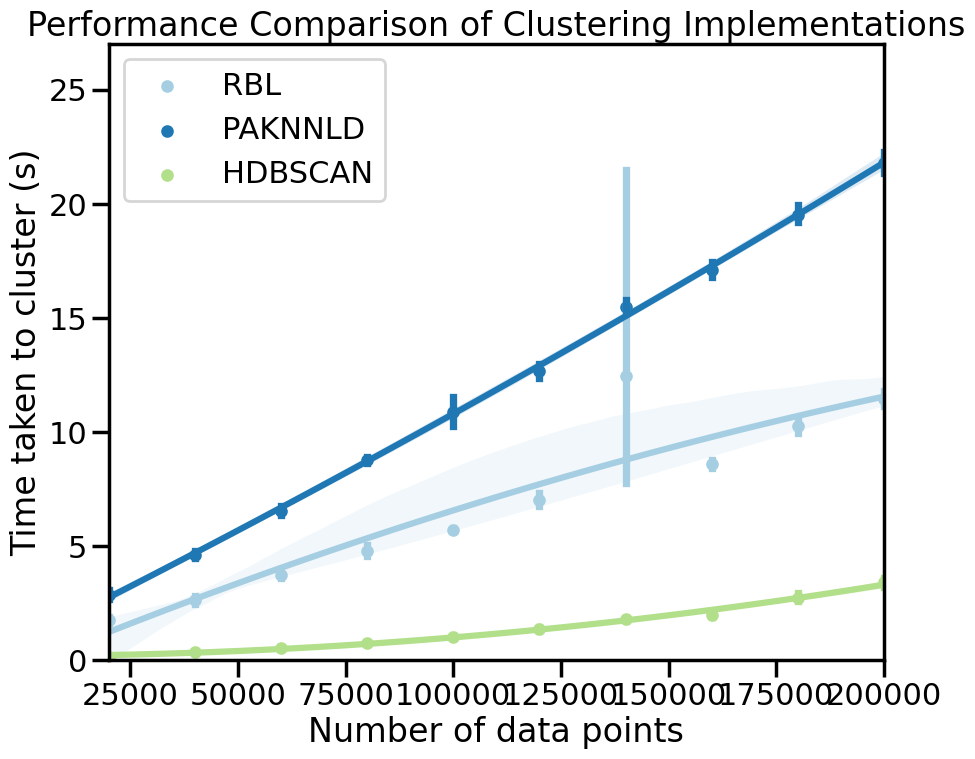

In [9]:
# Huge Data
huge_dataset_sizes = np.arange(1,11) * 20000

# Data to fit each model to compile the numba parts
data, labels = sklearn.datasets.make_blobs(n_samples=100, n_features=3, centers=2)

huge_rbl = tripletclustering.TripletClustering(similarity_method="rbl")
huge_rbl.fit(data)
huge_rbl_data = benchmark_algorithm(huge_dataset_sizes, rbl.fit, (), {})

huge_paknnld = tripletclustering.TripletClustering(similarity_method="paknnld")
huge_paknnld.fit(data)
huge_paknnld_data = benchmark_algorithm(huge_dataset_sizes, paknnld.fit, (), {})

huge_hdbscan = fast_hdbscan.HDBSCAN()
huge_hdbscan.fit(data)
huge_hdbscan_data = benchmark_algorithm(huge_dataset_sizes, hdbscan.fit, (), {})

plt.figure(figsize=(10, 8))

sns.regplot(x='x', y='y', data=huge_rbl_data, order=2, 
            label='RBL', x_estimator=np.mean)

sns.regplot(x='x', y='y', data=huge_paknnld_data, order=2, 
            label='PAKNNLD', x_estimator=np.mean)

sns.regplot(x='x', y='y', data=huge_hdbscan_data, order=2, 
            label='HDBSCAN', x_estimator=np.mean)

plt.gca().axis([np.min(huge_dataset_sizes), np.max(huge_dataset_sizes), 0, 27])
plt.gca().set_xlabel('Number of data points')
plt.gca().set_ylabel('Time taken to cluster (s)')
plt.title('Performance Comparison of Clustering Implementations')
plt.legend()
plt.show()

# Scaling with respect to number of neighbors (K)

In [10]:
def benchmark_algorithm(
    n_neighbors,
    cluster_object,
    dataset_size=10000,
    dataset_dimension=10,
    dataset_n_clusters=10,
    max_time=45,
    sample_size=5
    ):
    
    # Initialize the result with NaNs so that any unfilled entries 
    # will be considered NULL when we convert to a pandas dataframe at the end
    result = np.nan * np.ones((len(n_neighbors), sample_size))
    for index, n in enumerate(n_neighbors):
        for s in range(sample_size):
            # Use sklearns make_blobs to generate a random dataset with specified size
            # dimension and number of clusters
            data, labels = sklearn.datasets.make_blobs(n_samples=dataset_size, 
                                                        n_features=dataset_dimension, 
                                                        centers=dataset_n_clusters)
            cluster_object.n_neighbors = n
            # Start the clustering with a timer
            start_time = time.time()
            cluster_object.fit(data)
            time_taken = time.time() - start_time
            
            # If we are taking more than max_time then abort -- we don't
            # want to spend excessive time on slow algorithms
            if time_taken > max_time:
                result[index, s] = time_taken
                return pd.DataFrame(np.vstack([n_neighbors.repeat(sample_size), 
                                                result.flatten()]).T, columns=['x','y'])
            else:
                result[index, s] = time_taken
        
    # Return the result as a dataframe for easier handling with seaborn afterwards
    return pd.DataFrame(np.vstack([n_neighbors.repeat(sample_size), 
                                    result.flatten()]).T, columns=['x','y'])


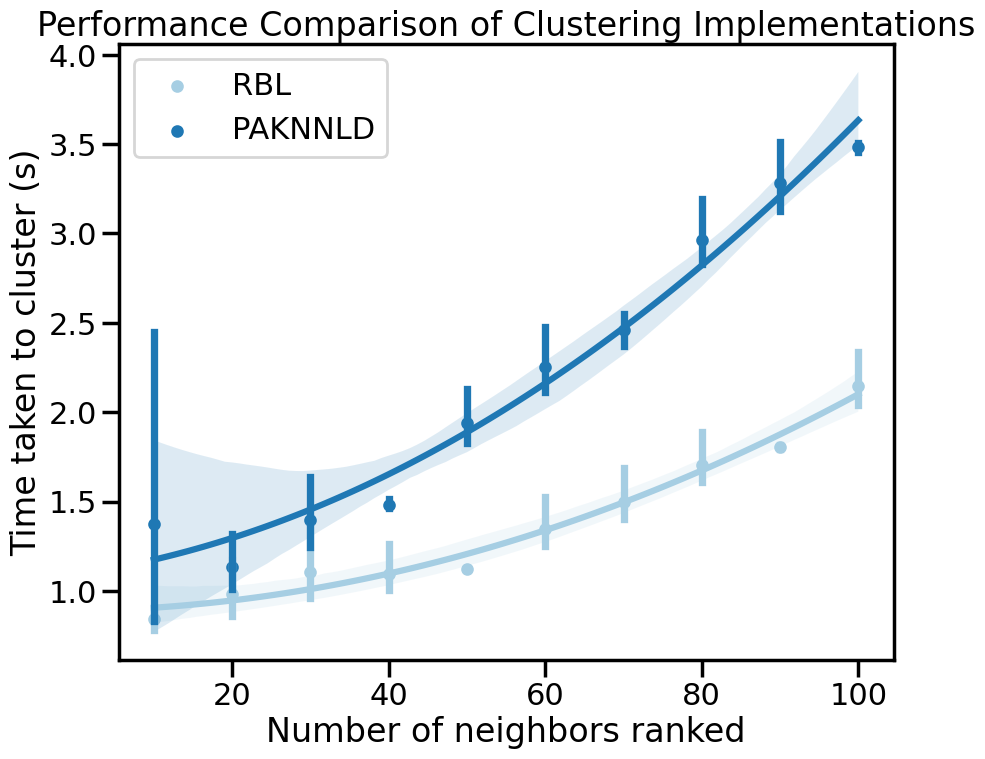

In [12]:
# Test scaling of n_neighbors
n_neighbors = np.arange(10) * 10 + 10

n_rbl = tripletclustering.TripletClustering(similarity_method="rbl")
n_rbl_data = benchmark_algorithm(n_neighbors, n_rbl)

n_paknnld = tripletclustering.TripletClustering(similarity_method="paknnld")
n_paknnld_data = benchmark_algorithm(n_neighbors, n_paknnld)

plt.figure(figsize=(10, 8))

sns.regplot(x='x', y='y', data=n_rbl_data, order=2, 
            label='RBL', x_estimator=np.mean)

sns.regplot(x='x', y='y', data=n_paknnld_data, order=2, 
            label='PAKNNLD', x_estimator=np.mean)

plt.gca().set_xlabel('Number of neighbors ranked')
plt.gca().set_ylabel('Time taken to cluster (s)')
plt.title('Performance Comparison of Clustering Implementations')
plt.legend()
plt.show()